# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
print(plans.head()) # mostrar las primeras 5 filas de plans

  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [4]:
print(users.head()) # mostrar las primeras 5 filas de users

   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [5]:
print(usage.head()) # mostrar las primeras 5 filas de usage

   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print(users.isna().mean()) # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())

print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Mi comentario** : En users, la columna city tiene 11.725% de valores nulos, por lo que se recomienda investigar e imputar si es posible. churn_date tiene 88.35% de nulos, pero estos pueden indicar que los usuarios continúan activos, por lo que se recomienda conservarlos como nulos. En usage, date tiene solamente 0.125% de nulos, por lo que puede revisarse o imputarse. Las columnas duration (55.19%) y length (44.74%) tienen muchos nulos, pero probablemente son valores que no aplican según el tipo de registro (call o text), por lo que se recomienda conservarlos y no imputarlos automáticamente.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
print(users[['user_id', 'age']].describe()) # explorar columnas numéricas de users

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` contiene los identificadores de los usuarios y no presenta valores nulos.
- La columna `age` contiene las edades y sus valores deben estar dentro de un rango razonable; se observan valores inválidos evidentes como -999, lo cual es importante revisar.

In [13]:
print(usage[['id', 'user_id', 'duration', 'length']].describe()) # explorar columnas numéricas de usage

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`contienen identificadores positivos y no presentan valores inválidos evidentes.
- Las columnas duration y length tienen valores mínimos de 0 y no presentan valores negativos. Sus valores máximos son 120 y 1490, respectivamente. También presentan valores nulos que deberán analizarse.

In [14]:
print((usage['duration'] == usage['duration'].max()).sum())
print((usage['length'] == usage['length'].max()).sum())

30
30


In [15]:
# Máscara para los valores máximos
max_duration = usage['duration'] == usage['duration'].max()
max_length = usage['length'] == usage['length'].max()

# Filas que tienen ambos máximos
ambos_maximos = max_duration & max_length

print("Filas con máximo en duration:", max_duration.sum())
print("Filas con máximo en length:", max_length.sum())
print("Filas con ambos máximos:", ambos_maximos.sum())

Filas con máximo en duration: 30
Filas con máximo en length: 30
Filas con ambos máximos: 0


In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(f"\nValores únicos de {columna}:")
    print(users[columna].unique())


Valores únicos de city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Valores únicos de plan:
['Basico' 'Premium']


- La columna `city` contiene ciudades válidas, pero también aparece el valor '?', que es un posible sentinel que representa información desconocida. Además, existen valores nulos (NaN), por lo que se recomienda investigar y tratar estos valores.
- La columna `plan`contiene únicamente los valores Basico y Premium, por lo que no se observan valores inválidos o inconsistentes.

In [17]:
# explorar columna categórica de usage
print(usage['type'].unique())# completa el código

['call' 'text']


- La columna `type`contiene únicamente los valores call y text, que representan los tipos de actividad. No se observan valores inválidos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?




**Mi Comentario**: En la columna city de users encontré el valor '?', que representa un dato desconocido o inválido.
considero importante reemplazar '?' por un valor nulo (NaN) y posteriormente analizar si es posible imputar la ciudad o mantenerla como desconocida.
Las demás columnas categóricas revisadas (plan y type) no presentan valores inválidos evidentes.
En las columnas numéricas (id, user_id, duration y length) no se encontraron valores negativos pero hay valores en duration con 120 minutos y length con 1490 hice una validación y ambos tienen 30 veces  repetido este dato es "es importante profundizar porque sospecho que son valores centinela dado que se repiten exactamente 30 veces cada uno y no se solapan.





### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [19]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')  # completa el código


In [20]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, Se ven 4 años (2022, 2023, 2024 y 2026), no se evidencia el año 2025, la cantidad de datos coincide ya que dan los 4000 datos registrados. 
Para el año 2026 se hay una fecha exacta que se repite 40 veces (2026-05-10) al igual que en el caso de  duration=120, length=1490, se ve en reg_date=2026-05-10) podria verse una repetición exacta 30/30/40 veces en filas distintas y no relacionadas,
Podrían significar valores centinela (por ejemplo: registros incompletos, datos faltantes marcados intencionalmente, o un placeholder del sistema)es prácticamente imposible que ocurra por azar.

In [21]:

users_2026 = users[users['reg_date'].dt.year == 2026]

print(users_2026['reg_date'])

40     2026-05-10
56     2026-05-10
60     2026-05-10
70     2026-05-10
248    2026-05-10
320    2026-05-10
326    2026-05-10
505    2026-05-10
527    2026-05-10
646    2026-05-10
885    2026-05-10
914    2026-05-10
948    2026-05-10
986    2026-05-10
1047   2026-05-10
1210   2026-05-10
1275   2026-05-10
1293   2026-05-10
1314   2026-05-10
1627   2026-05-10
1679   2026-05-10
1722   2026-05-10
1736   2026-05-10
1737   2026-05-10
1862   2026-05-10
1880   2026-05-10
1896   2026-05-10
2055   2026-05-10
2093   2026-05-10
2111   2026-05-10
2162   2026-05-10
2184   2026-05-10
2200   2026-05-10
2235   2026-05-10
2307   2026-05-10
2475   2026-05-10
2743   2026-05-10
3035   2026-05-10
3299   2026-05-10
3988   2026-05-10
Name: reg_date, dtype: datetime64[ns]


In [22]:
print(users_2026['reg_date'].nunique())

1


In [23]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, se evidencia que el resultado es diferente a lo encontrado en reg_date ya que aparecian 4 años, aqui podemos ver el año 2024 con 39950 valores no nulos. 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
**Mi comentario**:Se identificaron 40 registros con el año 2026 en reg_date. Al revisar las fechas, se observa que las 40 filas tienen exactamente la misma fecha (2026-05-10), por lo que la hipótesis de que se trata de un valor centinela o marcador ficticio se fortalece. Además, 2026 está fuera del rango esperado de los demás registros (2022–2024).
  **Acción recomendada**: No eliminaría los registros inmediatamente. Primero investigaría el origen de esta fecha para confirmar si 2026-05-10 representa un marcador del sistema o un error de captura. Si se confirma que es un valor centinela, lo reemplazaría por NaN para tratarlo posteriormente como un dato faltante.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [24]:

# Reemplazar -999 por la mediana de age
age_mediana =  users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [25]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [26]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [27]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage['duration'].isna().groupby(usage['type']).mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [28]:
# Verificación MAR en usage (Missing At Random) para length
print(usage['length'].isna().groupby(usage['type']).mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length
**Diagnóstico de nulos en duration y length:**
Los nulos de duration y length son principalmente nulos estructurales, determinados por la naturaleza del registro. duration no aplica a los mensajes de tipo text, mientras que length no aplica a las llamadas de tipo call. Esto se confirma porque prácticamente todos los registros de esos tipos presentan el valor nulo correspondiente. Por lo tanto, se deben mantener como nulos y no imputarlos, ya que asignarles valores artificiales podría introducir información incorrecta.

In [29]:
usage.loc[usage['duration'].isna(), 'type'].value_counts(dropna=False)

text    22076
Name: type, dtype: int64

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [30]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# 1. Combinar users con las métricas de usage
user_profile = users.merge(usage_agg, on="user_id", how="left")

# 2. Los usuarios sin actividad tienen 0 registros
user_profile[
    ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
] = user_profile[
    ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
].fillna(0)

# 3. Convertir a entero solamente los conteos
user_profile["cant_mensajes"] = user_profile["cant_mensajes"].astype(int)
user_profile["cant_llamadas"] = user_profile["cant_llamadas"].astype(int)

# 4. Verificar tipos
print(user_profile[
    ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
].dtypes)

cant_mensajes             int64
cant_llamadas             int64
cant_minutos_llamada    float64
dtype: object


In [33]:
# Combinar la tabla agregada con el dataset de usuarios


user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile["cant_mensajes"] = user_profile["cant_mensajes"].round().astype("Int64")
user_profile["cant_llamadas"] = user_profile["cant_llamadas"].round().astype("Int64")

user_profile.head(5)



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [34]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()


,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [35]:

# Distribución porcentual del tipo de plan

user_profile["plan"].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

In [36]:
# Comparar el comportamiento de uso según el plan
user_profile.groupby("plan")[
    ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
].mean()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
plan,,,
Basico,5.527756,4.456438,22.905436
Premium,5.518149,4.518149,24.077011


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

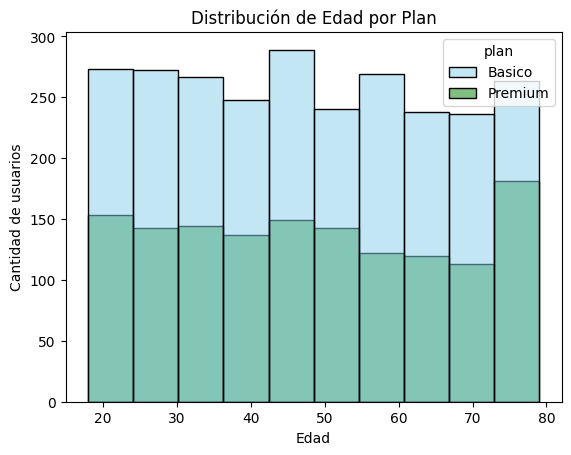

In [37]:

# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    bins=10
)

plt.title("Distribución de Edad por Plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()


💡Insights: 
- Distribución de age permite observar cómo se concentran las edades de los usuarios Básico y Premium.
Si ambas distribuciones tienen una forma similar, no habría una diferencia clara de edad entre los planes.
La forma de la distribución puede evaluarse visualmente como aproximadamente simétrica o sesgada.

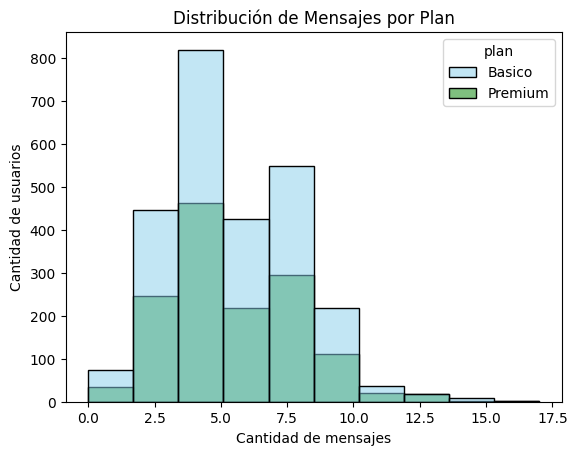

In [38]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"],
    bins=10
)

plt.title("Distribución de Mensajes por Plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- Permite comparar la cantidad de mensajes enviados entre Básico y Premium.
Si ambas distribuciones se superponen bastante, no existe un patrón claramente diferente entre los planes.
Si una distribución se concentra en valores mayores, ese plan presenta mayor cantidad de mensajes.
Por los estadísticos que vimos anteriormente, la distribución parece relativamente equilibrada, aunque puede presentar cierta cola hacia la derecha.

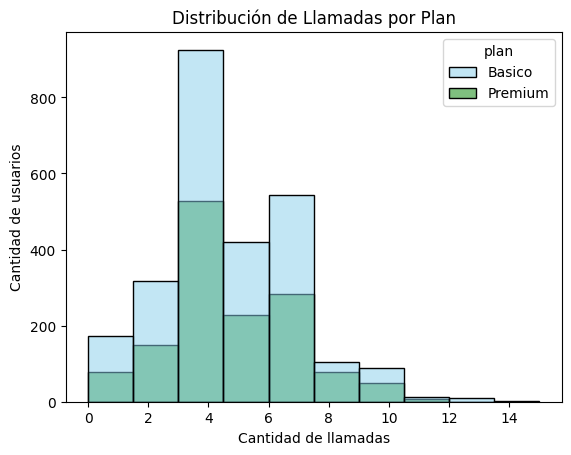

In [39]:
# Histograma para visualizar la cantidad de llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    bins=10
)

plt.title("Distribución de Llamadas por Plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- Permite identificar si los usuarios Premium realizan más llamadas que los usuarios Básico.
Si las distribuciones están muy superpuestas, no existe una diferencia marcada en la cantidad de llamadas según el plan.
La distribución parece relativamente equilibrada, aunque puede existir una ligera asimetría hacia la derecha debido a los usuarios con mayor cantidad de llamadas.

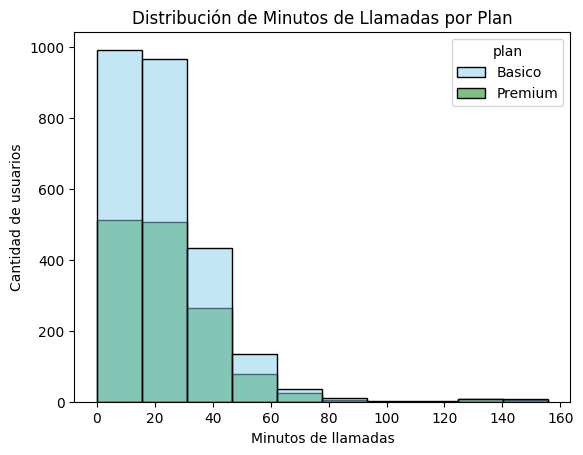

In [40]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"],
    bins=10
)

plt.title("Distribución de Minutos de Llamadas por Plan")
plt.xlabel("Minutos de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- Aquí esperamos encontrar algo especialmente interesante: anteriormente vimos que la media (23.32) es mayor que la mediana (19.78) y que existe un máximo de 155.69 minutos frente a un 75% de 31.42 minutos. Esto apunta a una distribución sesgada hacia la derecha, con algunos usuarios que consumen muchos más minutos que la mayoría.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

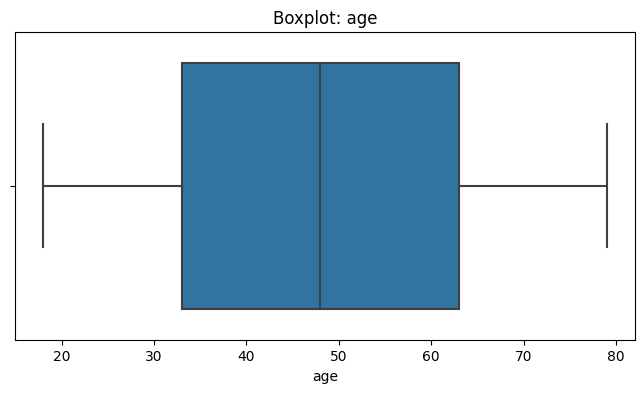

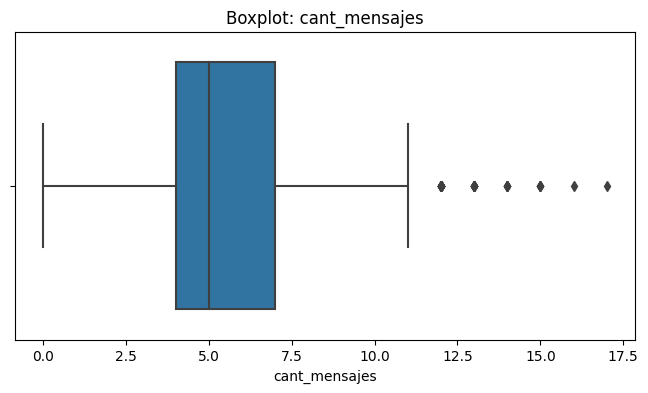

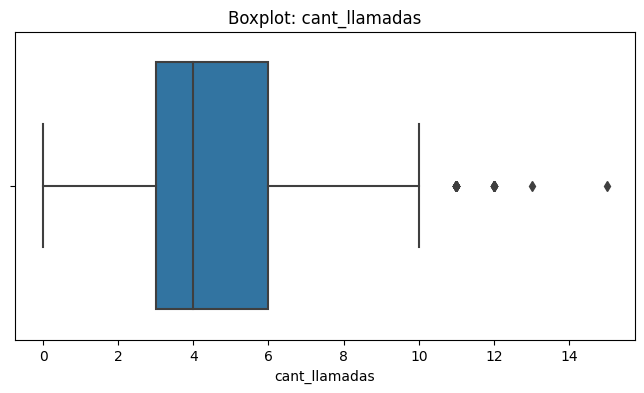

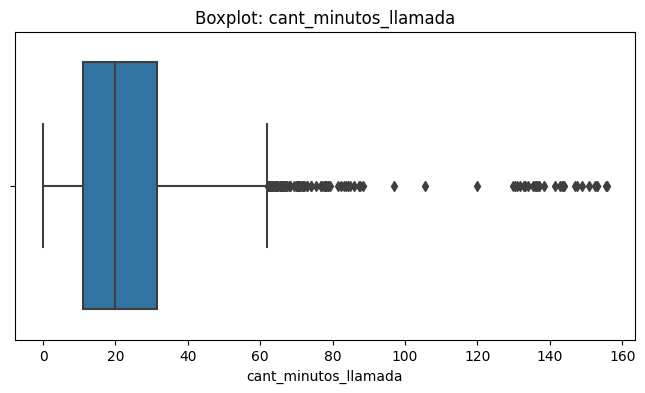

In [41]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: no se observan valores extremos evidentes; las edades están entre 18 y 79 años.
- cant_mensajes: puede presentar algunos valores altos, pero deben revisarse con IQR antes de decidir si son outliers.
- cant_llamadas: puede presentar algunos valores altos; también conviene comprobarlos con IQR.
- cant_minutos_llamada: sí es la variable que más claramente puede presentar outliers. El máximo de 155.69 está muy alejado del 75% (31.415).

In [42]:
# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f'\n{col}')
    print(f'Límite inferior: {limite_inferior:.2f}')
    print(f'Límite superior: {limite_superior:.2f}')
    print(f'Máximo: {user_profile[col].max():.2f}')



cant_mensajes
Límite inferior: -0.50
Límite superior: 11.50
Máximo: 17.00

cant_llamadas
Límite inferior: -1.50
Límite superior: 10.50
Máximo: 15.00

cant_minutos_llamada
Límite inferior: -19.32
Límite superior: 61.86
Máximo: 155.69


In [43]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
Los outliers de cant_mensajes, cant_llamadas y cant_minutos_llamada deberían mantenerse en el análisis. Aunque estadísticamente son valores atípicos según el método IQR, no son valores imposibles y pueden representar usuarios con un consumo elevado. Por lo tanto, no hay suficiente evidencia para considerarlos errores de datos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [44]:
print(user_profile['cant_llamadas'].dtype)
print(user_profile['cant_mensajes'].dtype)

Int64
Int64


In [45]:
condicion = (
    (user_profile['cant_llamadas'] < 5) &
    (user_profile['cant_mensajes'] < 5)
)

print(type(condicion))
print(condicion.dtype)

<class 'pandas.core.series.Series'>
boolean


In [46]:
# Reemplazar valores faltantes por 0
user_profile['cant_llamadas'] = user_profile['cant_llamadas'].fillna(0)
user_profile['cant_mensajes'] = user_profile['cant_mensajes'].fillna(0)

In [47]:

import numpy as np

# Crear columna grupo_uso

condiciones = [
    (
        (user_profile['cant_llamadas'] < 5) &
        (user_profile['cant_mensajes'] < 5)
    ).fillna(False).astype(bool),

    (
        (user_profile['cant_llamadas'] < 10) &
        (user_profile['cant_mensajes'] < 10)
    ).fillna(False).astype(bool)
]

grupos = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(
    condiciones,
    grupos,
    default='Alto uso'
)

In [48]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [51]:
# Crear columna grupo_edad
condiciones_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

grupos_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(
    condiciones_edad,
    grupos_edad,
    default='Adulto Mayor')

In [52]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


In [55]:
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

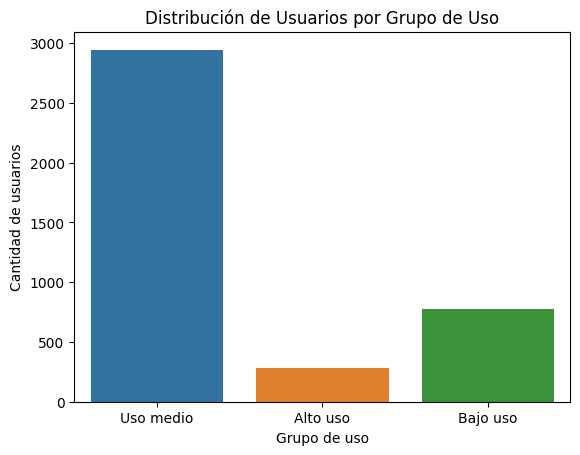

In [56]:

# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()


In [58]:
user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64

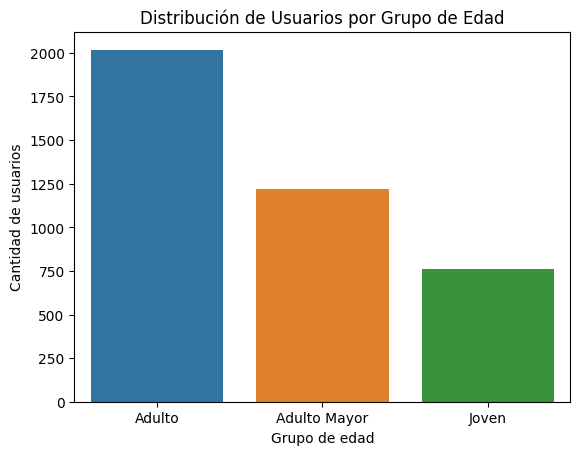

In [57]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se encontraron valores sentinel -999 en la columna age, que representaban datos inválidos. Fueron reemplazados por la mediana de edad.
- En city se encontró el valor ?, utilizado como dato desconocido, por lo que se convirtió en valor nulo.
- En reg_date había 40 fechas con años posteriores a 2024, por lo que se consideraron fechas inválidas y se reemplazaron por valores nulos.
- En usage, los valores faltantes de duration y length eran principalmente estructurales: los mensajes de texto no tienen duración de llamada y las llamadas no tienen longitud de mensaje.


🔍 **Segmentos por Edad**
- Joven: menores de 30 años.
- Adulto: de 30 a 59 años.
- Adulto Mayor: 60 años o más.
- La edad promedio es de aproximadamente 48 años, por lo que el segmento adulto representa una parte importante de la base de clientes 2018 de 4000 clientes.


📊 **Segmentos por Nivel de Uso**
- Bajo uso: menos de 5 llamadas y menos de 5 mensajes.
- Uso medio: menos de 10 llamadas y menos de 10 mensajes.
- Alto uso: 10 o más llamadas o mensajes.
- En promedio, los clientes realizan 4,48 llamadas y 5,52 mensajes, mientras que consumen aproximadamente 23,32 minutos de llamadas evidenciando un Uso medio de 2943, un Bajo uso 779, y un Alto uso 278 usuarios.


➡️ Esto sugiere que **ConnectaTel** tiene una base de clientes principalmente adulta, con un consumo moderado de llamadas y mensajes, pero también existen usuarios de alto consumo que pueden representar oportunidades comerciales importantes


💡 **Recomendaciones**
- Crear o fortalecer planes diferenciados para usuarios de alto consumo, especialmente aquellos que superan los niveles habituales de llamadas, mensajes y minutos.
- Diseñar planes económicos para usuarios de bajo consumo.
- Analizar los usuarios con consumos extremos antes de considerarlos errores. Se identificaron valores superiores a 11 mensajes, 10 llamadas y aproximadamente 62 minutos de llamadas, llegando hasta 17 mensajes, 15 llamadas y 155,69  minutos. Estos clientes podrían representar oportunidades para planes Premium o planes de mayor capacidad.
- Utilizar la combinación de edad + nivel de uso para crear ofertas más personalizadas.
**Conclusión ejecutiva**: **ConnectaTel** podría mejorar sus ingresos y retención si deja de ofrecer una propuesta demasiado general y utiliza los segmentos de edad + nivel de uso para personalizar sus planes y promociones.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: [Repositorio en GitHub](https://github.com/Calmanza79/sprint7-final-project/blob/main/S7%20Version-Estudiante-Project-ConnectaTel.ipynb)